# 第10章：统计学与投资组合优化

基于《Python金融大数据分析（第2版）》第13章的 **13.1 正态性检验** 与
**13.2 投资组合优化**。本 notebook 直接使用仓库中原书配套的日终价格数据，
不需要网络连接。

## Goal

完成本章后，你应能：

1. 用图形和统计检验判断收益率是否近似正态；
2. 用收益率均值、协方差和权重计算组合的年化收益与波动率；
3. 在“仅做多、权重和为 1”的约束下求最大夏普比率、最小方差组合；
4. 绘制有效边界和包含无风险资产的资本市场线。

## Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, stats

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.unicode_minus": False,
        "font.family": "sans-serif",
        "font.sans-serif": ["Microsoft YaHei", "SimHei", "DejaVu Sans"],
    }
)


def project_root(start: Path = Path.cwd()) -> Path:
    """Find the repository root so the notebook runs from any subdirectory."""
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("未找到项目根目录（pyproject.toml）。")


ROOT = project_root()
DATA_PATH = ROOT / "原书代码" / "source" / "tr_eikon_eod_data.csv"
FIGURE_DIR = ROOT / "Chapter10 slides - 统计学与投资组合优化" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TRADING_DAYS = 252
RISK_FREE_RATE = 0.01
ASSETS = ["AAPL.O", "MSFT.O", "SPY", "GLD"]

print(f"数据文件：{DATA_PATH.relative_to(ROOT)}")
print(f"图片目录：{FIGURE_DIR.relative_to(ROOT)}")

数据文件：原书代码\source\tr_eikon_eod_data.csv
图片目录：Chapter10 slides - 统计学与投资组合优化\figures


### Key assumptions

- 日度对数收益用 `log(P_t / P_{t-1})` 计算，并按每年 252 个交易日年化。
- 历史平均收益和历史协方差被当作未来的估计；这是均值-方差模型的教学假设，
  不是投资建议。
- 组合优化只允许做多：每个权重位于 0 和 1 之间，且权重之和为 1。

## Steps

### 1. 读取价格数据并计算对数收益率

In [2]:
raw_prices = pd.read_csv(DATA_PATH, index_col=0, parse_dates=True).dropna(how="all")
prices = raw_prices[ASSETS].dropna().copy()
log_returns = np.log(prices / prices.shift(1)).dropna()

print(f"样本区间：{prices.index.min():%Y-%m-%d} 至 {prices.index.max():%Y-%m-%d}")
print(f"有效交易日：{len(log_returns):,}")
display(prices.head())

样本区间：2010-01-04 至 2018-06-29
有效交易日：2,137


,AAPL.O,MSFT.O,SPY,GLD
Date,,,,
2010-01-04,30.572827,30.950,113.33,109.80
2010-01-05,30.625684,30.960,113.63,109.70
2010-01-06,30.138541,30.770,113.71,111.51
2010-01-07,30.082827,30.452,114.19,110.82
2010-01-08,30.282827,30.660,114.57,111.37


### 2. 基准案例：几何布朗运动的对数收益率

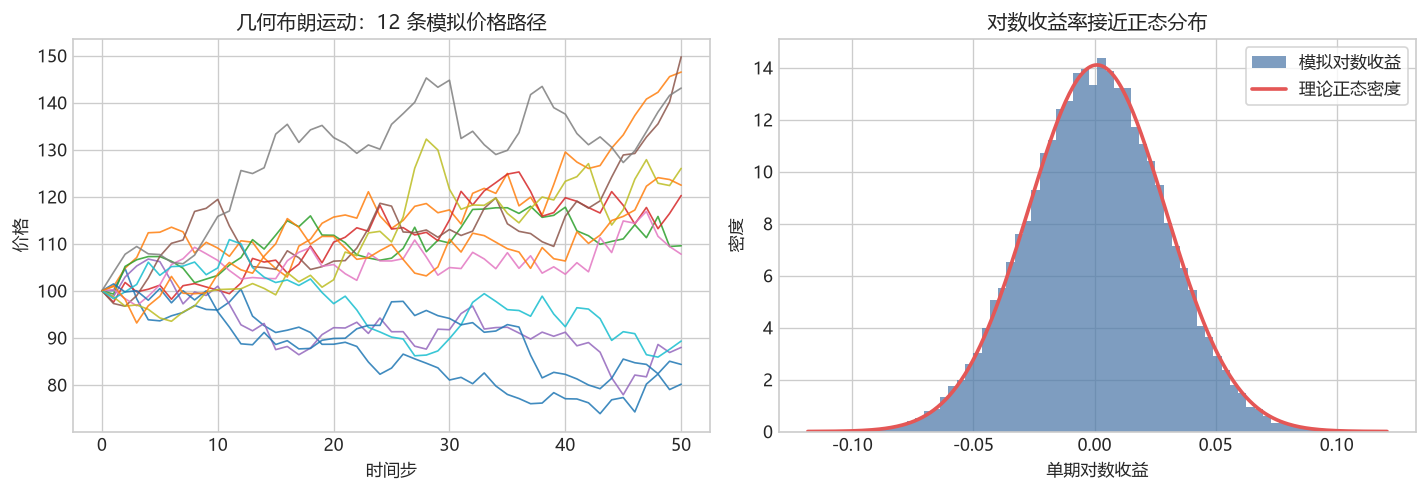

,GBM 对数收益率
偏度,-0.0227
超额峰度,-0.0126
偏度检验 p 值,0.0382
峰度检验 p 值,0.5731
正态性检验 p 值,0.0995


In [3]:
def gbm_paths(S0=100.0, r=0.05, sigma=0.20, T=1.0, steps=50, paths=25_000, seed=7):
    """Simulate geometric-Brownian-motion price paths with reproducible random draws."""
    rng = np.random.default_rng(seed)
    dt = T / steps
    shocks = rng.standard_normal((steps, paths))
    simulated = np.empty((steps + 1, paths))
    simulated[0] = S0
    for t in range(1, steps + 1):
        simulated[t] = simulated[t - 1] * np.exp(
            (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * shocks[t - 1]
        )
    return simulated


paths = gbm_paths()
gbm_log_returns = np.log(paths[1:] / paths[:-1]).ravel()[::25]
gbm_mean = 0.05 / 50
gbm_std = 0.20 / np.sqrt(50)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(paths[:, :12], lw=1.0, alpha=0.85)
axes[0].set(title="几何布朗运动：12 条模拟价格路径", xlabel="时间步", ylabel="价格")

axes[1].hist(gbm_log_returns, bins=70, density=True, color="#4C78A8", alpha=0.72, label="模拟对数收益")
grid = np.linspace(gbm_log_returns.min(), gbm_log_returns.max(), 300)
axes[1].plot(grid, stats.norm.pdf(grid, gbm_mean, gbm_std), color="#E45756", lw=2.2, label="理论正态密度")
axes[1].set(title="对数收益率接近正态分布", xlabel="单期对数收益", ylabel="密度")
axes[1].legend(frameon=True)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "ch10_gbm_normality.png", bbox_inches="tight")
plt.show()

benchmark_tests = pd.Series(
    {
        "偏度": stats.skew(gbm_log_returns),
        "超额峰度": stats.kurtosis(gbm_log_returns),
        "偏度检验 p 值": stats.skewtest(gbm_log_returns).pvalue,
        "峰度检验 p 值": stats.kurtosistest(gbm_log_returns).pvalue,
        "正态性检验 p 值": stats.normaltest(gbm_log_returns).pvalue,
    }
)
display(benchmark_tests.to_frame("GBM 对数收益率").round(4))

### 3. 真实收益率：QQ 图与正态性检验

,偏度,超额峰度,正态性检验 p 值,5% 水平结论
AAPL.O,-0.2351,4.7896,0.0,拒绝正态性
MSFT.O,-0.0912,7.2911,0.0,拒绝正态性
SPY,-0.5219,4.5243,0.0,拒绝正态性
GLD,-0.5993,5.6842,0.0,拒绝正态性


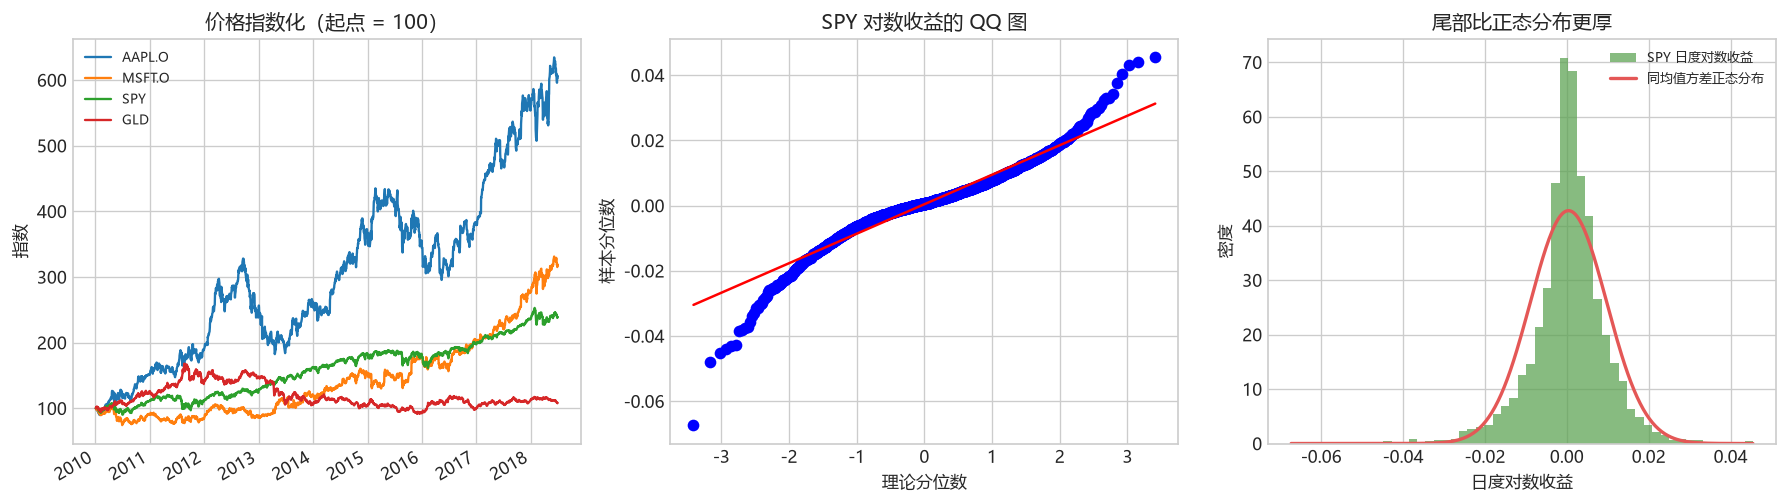

In [4]:
def normality_summary(series: pd.Series) -> pd.Series:
    """Return interpretable normality diagnostics for one return series."""
    values = series.dropna().to_numpy()
    return pd.Series(
        {
            "偏度": stats.skew(values),
            "超额峰度": stats.kurtosis(values),
            "正态性检验 p 值": stats.normaltest(values).pvalue,
        }
    )


normality_table = log_returns.apply(normality_summary).T
normality_table["5% 水平结论"] = np.where(
    normality_table["正态性检验 p 值"] < 0.05, "拒绝正态性", "未拒绝正态性"
)
display(normality_table.round(4))

normalized = prices / prices.iloc[0] * 100
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
normalized.plot(ax=axes[0], lw=1.4)
axes[0].set(title="价格指数化（起点 = 100）", xlabel="", ylabel="指数")
axes[0].legend(fontsize=8)

stats.probplot(log_returns["SPY"], dist="norm", plot=axes[1])
axes[1].set(title="SPY 对数收益的 QQ 图", xlabel="理论分位数", ylabel="样本分位数")

axes[2].hist(log_returns["SPY"], bins=55, density=True, color="#59A14F", alpha=0.72, label="SPY 日度对数收益")
x = np.linspace(log_returns["SPY"].min(), log_returns["SPY"].max(), 300)
axes[2].plot(x, stats.norm.pdf(x, log_returns["SPY"].mean(), log_returns["SPY"].std()), color="#E45756", lw=2.0, label="同均值方差正态分布")
axes[2].set(title="尾部比正态分布更厚", xlabel="日度对数收益", ylabel="密度")
axes[2].legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "ch10_real_data_normality.png", bbox_inches="tight")
plt.show()

### 4. 组合的收益、风险与随机权重

年化平均收益率


,年化收益率（%）
AAPL.O,21.24
MSFT.O,13.66
SPY,10.29
GLD,0.91


年化协方差矩阵


,AAPL.O,MSFT.O,SPY,GLD
AAPL.O,0.0638,0.0234,0.0210,0.0015
MSFT.O,0.0234,0.0509,0.0222,-0.0003
SPY,0.0210,0.0222,0.0219,0.0001
GLD,0.0015,-0.0003,0.0001,0.0262


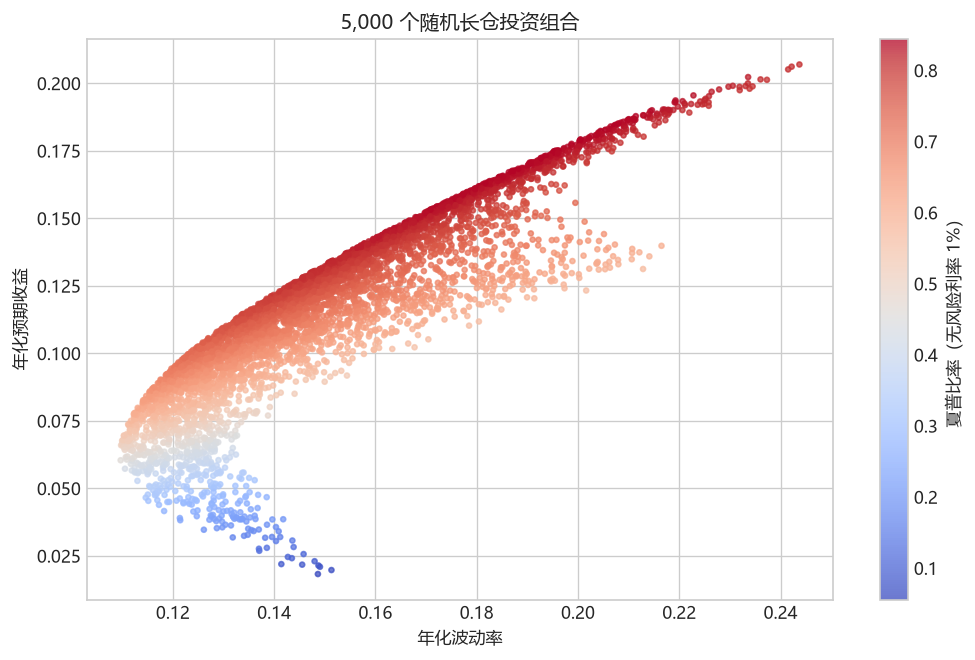

In [5]:
annual_returns = log_returns.mean() * TRADING_DAYS
annual_covariance = log_returns.cov() * TRADING_DAYS


def portfolio_return(weights: np.ndarray) -> float:
    return float(np.dot(annual_returns.to_numpy(), weights))


def portfolio_volatility(weights: np.ndarray) -> float:
    return float(np.sqrt(weights @ annual_covariance.to_numpy() @ weights))


rng = np.random.default_rng(42)
random_weights = rng.dirichlet(np.ones(len(ASSETS)), size=5_000)
random_returns = np.apply_along_axis(portfolio_return, 1, random_weights)
random_volatilities = np.apply_along_axis(portfolio_volatility, 1, random_weights)
random_sharpes = (random_returns - RISK_FREE_RATE) / random_volatilities

print("年化平均收益率")
display((annual_returns * 100).to_frame("年化收益率（%）").round(2))
print("年化协方差矩阵")
display(annual_covariance.round(4))

fig, ax = plt.subplots(figsize=(8.7, 5.6))
scatter = ax.scatter(random_volatilities, random_returns, c=random_sharpes, s=9, alpha=0.75, cmap="coolwarm")
ax.set(title="5,000 个随机长仓投资组合", xlabel="年化波动率", ylabel="年化预期收益")
fig.colorbar(scatter, ax=ax, label="夏普比率（无风险利率 1%）")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "ch10_random_portfolios.png", bbox_inches="tight")
plt.show()

### 5. 约束优化：最大夏普比率、最小方差与有效边界

In [6]:
noa = len(ASSETS)
equal_weights = np.repeat(1 / noa, noa)
bounds = tuple((0.0, 1.0) for _ in range(noa))
budget_constraint = {"type": "eq", "fun": lambda w: np.sum(w) - 1}


def negative_sharpe_ratio(weights: np.ndarray, risk_free_rate: float = RISK_FREE_RATE) -> float:
    return -(portfolio_return(weights) - risk_free_rate) / portfolio_volatility(weights)


max_sharpe = optimize.minimize(
    negative_sharpe_ratio,
    equal_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=budget_constraint,
)
min_variance = optimize.minimize(
    portfolio_volatility,
    equal_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=budget_constraint,
)

assert max_sharpe.success, max_sharpe.message
assert min_variance.success, min_variance.message

target_returns = np.linspace(portfolio_return(min_variance.x), annual_returns.max(), 60)
frontier_volatilities = []
for target in target_returns:
    result = optimize.minimize(
        portfolio_volatility,
        equal_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=(
            budget_constraint,
            {"type": "eq", "fun": lambda w, target=target: portfolio_return(w) - target},
        ),
    )
    if result.success:
        frontier_volatilities.append(result.fun)
    else:
        frontier_volatilities.append(np.nan)
frontier_volatilities = np.asarray(frontier_volatilities)

optimization_summary = pd.DataFrame(
    {
        "最大夏普比率组合": max_sharpe.x,
        "全局最小方差组合": min_variance.x,
    },
    index=ASSETS,
)
optimization_metrics = pd.DataFrame(
    {
        "年化收益率": [portfolio_return(max_sharpe.x), portfolio_return(min_variance.x)],
        "年化波动率": [portfolio_volatility(max_sharpe.x), portfolio_volatility(min_variance.x)],
    },
    index=["最大夏普比率组合", "全局最小方差组合"],
)
optimization_metrics["夏普比率（rf=1%）"] = (
    optimization_metrics["年化收益率"] - RISK_FREE_RATE
) / optimization_metrics["年化波动率"]

display(optimization_summary.round(4))
display(optimization_metrics.round(4))

,最大夏普比率组合,全局最小方差组合
AAPL.O,0.5894,0.0000
MSFT.O,0.2211,0.0011
SPY,0.1895,0.5433
GLD,0.0000,0.4557


,年化收益率,年化波动率,夏普比率（rf=1%）
最大夏普比率组合,0.1749,0.1952,0.8447
全局最小方差组合,0.0602,0.1094,0.4590


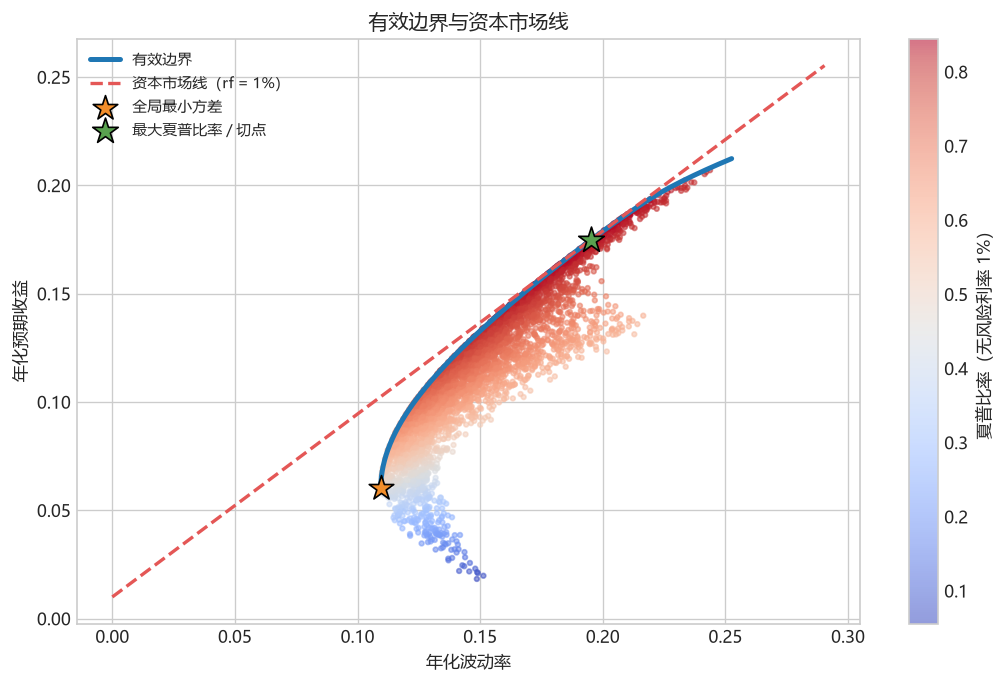

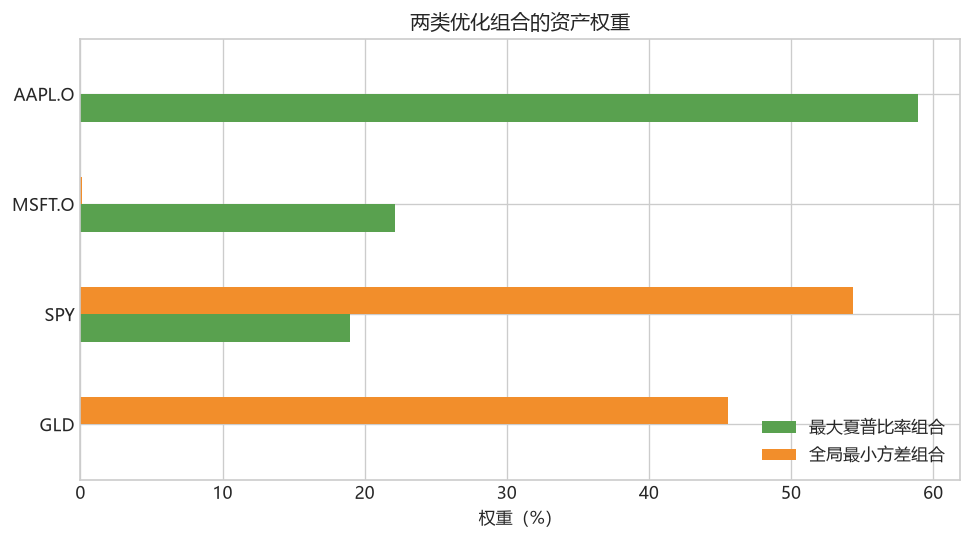

In [7]:
tangency_weights = max_sharpe.x
tangency_return = portfolio_return(tangency_weights)
tangency_volatility = portfolio_volatility(tangency_weights)
cml_x = np.linspace(0, max(np.nanmax(frontier_volatilities), tangency_volatility) * 1.15, 120)
cml_y = RISK_FREE_RATE + ((tangency_return - RISK_FREE_RATE) / tangency_volatility) * cml_x

fig, ax = plt.subplots(figsize=(9, 5.8))
scatter = ax.scatter(random_volatilities, random_returns, c=random_sharpes, s=8, alpha=0.55, cmap="coolwarm")
ax.plot(frontier_volatilities, target_returns, color="#1F77B4", lw=3, label="有效边界")
ax.plot(cml_x, cml_y, color="#E45756", lw=2, ls="--", label="资本市场线（rf = 1%）")
ax.scatter(portfolio_volatility(min_variance.x), portfolio_return(min_variance.x), marker="*", s=240, color="#F28E2B", edgecolor="black", zorder=5, label="全局最小方差")
ax.scatter(tangency_volatility, tangency_return, marker="*", s=260, color="#59A14F", edgecolor="black", zorder=6, label="最大夏普比率 / 切点")
ax.set(title="有效边界与资本市场线", xlabel="年化波动率", ylabel="年化预期收益")
ax.legend(loc="best", fontsize=9)
fig.colorbar(scatter, ax=ax, label="夏普比率（无风险利率 1%）")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "ch10_efficient_frontier_cml.png", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8.2, 4.6))
weight_frame = optimization_summary.mul(100).sort_values("最大夏普比率组合")
weight_frame.plot.barh(ax=ax, color=["#59A14F", "#F28E2B"])
ax.set(title="两类优化组合的资产权重", xlabel="权重（%）", ylabel="")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "ch10_optimized_weights.png", bbox_inches="tight")
plt.show()

## Checks

In [8]:
assert np.isclose(max_sharpe.x.sum(), 1.0)
assert np.isclose(min_variance.x.sum(), 1.0)
assert np.all(max_sharpe.x >= -1e-8) and np.all(max_sharpe.x <= 1 + 1e-8)
assert np.all(min_variance.x >= -1e-8) and np.all(min_variance.x <= 1 + 1e-8)
assert portfolio_volatility(min_variance.x) <= portfolio_volatility(equal_weights)
assert -negative_sharpe_ratio(max_sharpe.x) >= -negative_sharpe_ratio(equal_weights)

check_table = pd.DataFrame(
    {
        "等权重组合": [portfolio_return(equal_weights), portfolio_volatility(equal_weights), -negative_sharpe_ratio(equal_weights)],
        "最大夏普比率组合": [portfolio_return(max_sharpe.x), portfolio_volatility(max_sharpe.x), -negative_sharpe_ratio(max_sharpe.x)],
        "全局最小方差组合": [portfolio_return(min_variance.x), portfolio_volatility(min_variance.x), -negative_sharpe_ratio(min_variance.x)],
    },
    index=["年化收益率", "年化波动率", "夏普比率（rf=1%）"],
)
display(check_table.round(4))
print("检查通过：预算约束、长仓边界与优化改进均满足。")

,等权重组合,最大夏普比率组合,全局最小方差组合
年化收益率,0.1153,0.1749,0.0602
年化波动率,0.1366,0.1952,0.1094
夏普比率（rf=1%）,0.7704,0.8447,0.4590


检查通过：预算约束、长仓边界与优化改进均满足。


## Next Steps

1. 将 `RISK_FREE_RATE` 改为 0%、2% 和 3%，比较资本市场线和切点组合如何变化。
2. 允许卖空（放宽权重下界）后重新优化，讨论为何结果可能出现极端权重。
3. 改用滚动窗口估计收益和协方差，观察“历史最优”是否稳定。

**提醒：** 本 notebook 用历史样本演示均值-方差优化。实际投资还需考虑估计误差、
交易成本、流动性、约束和样本外检验；输出不构成投资建议。